# W03A Normal Approximation in Python
**ENGR 1451/2451: Exploratory Data Science**

Use one Iris sample to **inspect, fit, and compare**, then explore repeated averages with a dice simulation.

Keep the **observed sample** separate from the **fitted normal curve**: fitted percentages and percentiles need not match the data exactly.

## 1. Setup

Use the same `./data/iris.csv` as the descriptive-statistics notebook. Measurements are in centimeters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from IPython.display import display

iris = pd.read_csv("./data/iris.csv")

## 2. Normalize equal-width bins

Use the 20 teaching measurements from the slides. Every bin has width $w=2$:

$$
\text{proportion}=\frac{\text{count}}{n},\qquad
\text{density}=\frac{\text{proportion}}{w}.
$$

**Bar area = density × width.** The areas, not the heights, sum to 1. Bins should cover all observations.

In [2]:
measurements = np.array([
    0.5, 1.5,
    2.1, 2.4, 2.6, 2.9, 3.2, 3.8,
    4.1, 4.3, 4.6, 4.8, 5.1, 5.3, 5.5, 5.8,
    6.2, 6.7, 7.1, 7.8,
])
bins = np.array([0, 2, 4, 6, 8])
counts, edges = np.histogram(measurements, bins=bins)
bin_width = edges[1] - edges[0]
proportions = counts / measurements.size
densities = proportions / bin_width

display(pd.DataFrame({
    "Bin": ["[0, 2)", "[2, 4)", "[4, 6)", "[6, 8]"],
    "Count": counts,
    "Proportion": proportions,
    "Density": densities,
}))
print(f"Total histogram area: {(densities * bin_width).sum():.2f}")

,Bin,Count,Proportion,Density
0,"[0, 2)",2,0.1,0.05
1,"[2, 4)",6,0.3,0.15
2,"[4, 6)",8,0.4,0.20
3,"[6, 8]",4,0.2,0.10


Total histogram area: 1.00


## 3. Inspect the sample and fit a normal curve

Use **Versicolor sepal length**. Set the curve's center to $\bar{x}$ and its spread to $s$; `scale` takes $s$, not $s^2$. Use `ddof=1` for sample standard deviation.

`density=True` normalizes the histogram. `model.pdf(x)` gives a density height, not a probability. Check for one roughly symmetric mound, unusual values, or distinct groups before using the fit.

In [3]:
sample = iris.loc[iris["variety"] == "Versicolor", "sepal.length"].dropna()
mean_value = sample.mean()
std_value = sample.std(ddof=1)
model = norm(loc=mean_value, scale=std_value)

print(f"n = {sample.size}, mean = {mean_value:.3f} cm, s = {std_value:.3f} cm")

n = 50, mean = 5.936 cm, s = 0.516 cm


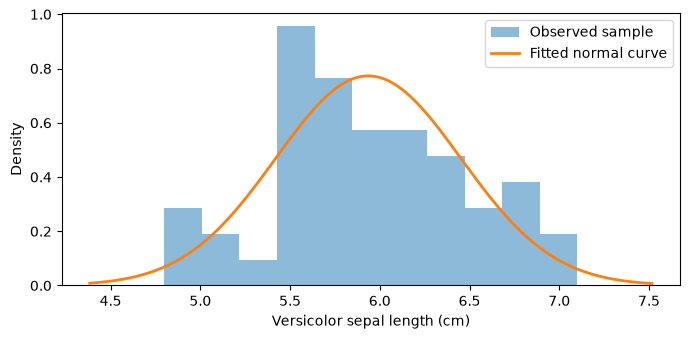

In [4]:
iris_bins = np.linspace(sample.min() - 0.1, sample.max() + 0.1, 12)
x_grid = np.linspace(sample.min() - std_value, sample.max() + std_value, 400)

plt.figure(figsize=(7, 3.5))
plt.hist(sample, bins=iris_bins, density=True, alpha=0.5, label="Observed sample")
plt.plot(x_grid, model.pdf(x_grid), linewidth=2, label="Fitted normal curve")
plt.xlabel("Versicolor sepal length (cm)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Compare observed and fitted percentages

`cdf(x)` gives fitted area **at or below** `x`; `sf(x)` gives area **above** `x`. Subtract two CDF values for an interval.

A Boolean condition followed by `.mean()` gives the **observed proportion**: `True` counts as 1 and `False` as 0. Multiply by 100 to report a percentage.

In [5]:
lower, upper = 5.5, 6.5

comparison = pd.DataFrame({
    "Question": ["At or below 5.5 cm", "Above 6.5 cm", "Between 5.5 and 6.5 cm"],
    "Observed (%)": [
        100 * (sample <= lower).mean(),
        100 * (sample > upper).mean(),
        100 * sample.between(lower, upper).mean(),
    ],
    "Fitted (%)": [
        100 * model.cdf(lower),
        100 * model.sf(upper),
        100 * (model.cdf(upper) - model.cdf(lower)),
    ],
})
comparison.round(2)

,Question,Observed (%),Fitted (%)
0,At or below 5.5 cm,22.0,19.91
1,Above 6.5 cm,16.0,13.73
2,Between 5.5 and 6.5 cm,72.0,66.36


## 5. Find a cutoff from a percentage

`ppf(p)` takes a **left-tail proportion** and returns a cutoff. `isf(p)` takes a **right-tail proportion** and returns a cutoff. For the 95th percentile, use `ppf(0.95)` or `isf(0.05)`—not `ppf(95)`.

Compare the fitted cutoff with `sample.quantile(0.95)`, which uses the actual observations and interpolation.

In [6]:
print(f"Sample 95th percentile: {sample.quantile(0.95):.3f} cm")
print(f"Fitted cutoff, 95% to the left: {model.ppf(0.95):.3f} cm")
print(f"Fitted cutoff, 5% to the right: {model.isf(0.05):.3f} cm")

Sample 95th percentile: 6.755 cm
Fitted cutoff, 95% to the left: 6.785 cm
Fitted cutoff, 5% to the right: 6.785 cm


## 6. CLT: repeated sums and averages

Simulate 5,000 experiments with 30 fair-die rolls in each. Each row is one experiment; `axis=1` calculates across the row. Compare sample means and standard deviations, then plot only the averages.

In [7]:
rng = np.random.default_rng(1451)
rolls_per_group = 30
rolls = rng.integers(1, 7, size=(5000, rolls_per_group))
single_rolls = rolls[:, 0]
group_sums = rolls.sum(axis=1)
group_means = rolls.mean(axis=1)

pd.DataFrame({
    "One roll": single_rolls,
    "Sum of 30": group_sums,
    "Average of 30": group_means,
}).agg(["mean", "std"]).round(3)

,One roll,Sum of 30,Average of 30
mean,3.529,104.810,3.494
std,1.704,9.499,0.317


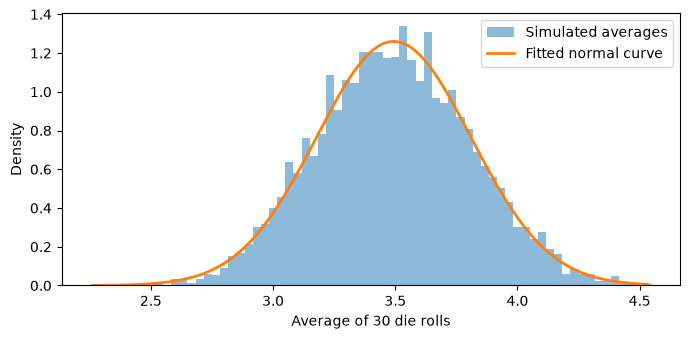

In [8]:
# Align equal-width bins with the possible averages of integer die rolls.
mean_bins = np.arange(group_sums.min() - 0.5, group_sums.max() + 1.5) / rolls_per_group
mean_model = norm(loc=group_means.mean(), scale=group_means.std(ddof=1))
mean_grid = np.linspace(group_means.min(), group_means.max(), 400)

plt.figure(figsize=(7, 3.5))
plt.hist(group_means, bins=mean_bins, density=True, alpha=0.5, label="Simulated averages")
plt.plot(mean_grid, mean_model.pdf(mean_grid), linewidth=2, label="Fitted normal curve")
plt.xlabel("Average of 30 die rolls")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

The **sum** has a larger center; the **average** stays near the single-roll center with less spread. Sums and averages have the same shape after rescaling. Their values remain discrete.

The CLT concerns repeated sums and averages of independent observations from the same process with finite, nonzero variance—not the shape of individual rolls. There is no universal group size that guarantees a good approximation.

**LLN versus CLT:** the LLN concerns an average stabilizing; the CLT concerns the approximately normal shape of repeated sums or averages. The slides illustrate the LLN separately.

## 7. Compact code reference

For the fitted `model`, `p` is a proportion from 0 to 1.

| Goal | Python pattern |
|---|---|
| Fit using $\bar{x}$ and $s$ | `norm(loc=sample.mean(), scale=sample.std(ddof=1))` |
| Density histogram | `plt.hist(sample, bins=bins, density=True)` |
| Density height | `model.pdf(x)` |
| Left / right area from a value | `model.cdf(x)` / `model.sf(x)` |
| Cutoff from left / right area | `model.ppf(p)` / `model.isf(p)` |
| Fitted interval proportion | `model.cdf(b) - model.cdf(a)` |
| Observed interval proportion | `sample.between(a, b).mean()` |
| Sample percentile | `sample.quantile(p)` |
| Standard units | `(sample - sample.mean()) / sample.std(ddof=1)` |

**Names:** `pdf` = probability density function; `cdf` = cumulative distribution function; `sf` = survival function; `ppf` = percent point function (inverse CDF); `isf` = inverse survival function.

*Sources:* supplied Normal Approximation slides and notebook. The teaching sample is constructed; the bundled Iris CSV is the same [scikit-learn export](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html) used in the earlier class package. [SciPy method reference](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html).

## 8. Your turn: assess a normal approximation

Use **Virginica sepal width** (`variety == "Virginica"`, column `"sepal.width"`).

1. Calculate $n$, $\bar{x}$, and $s$. Plot an equal-width density histogram with a fitted normal curve.
2. Compare the **observed and fitted percentages between 2.7 and 3.3 cm**. Report their difference in percentage points.
3. Compare the **sample and fitted 90th percentiles**. In 2–3 sentences, assess the approximation using the plot and numerical comparisons.

Use your own variable names so you do not overwrite the worked example.

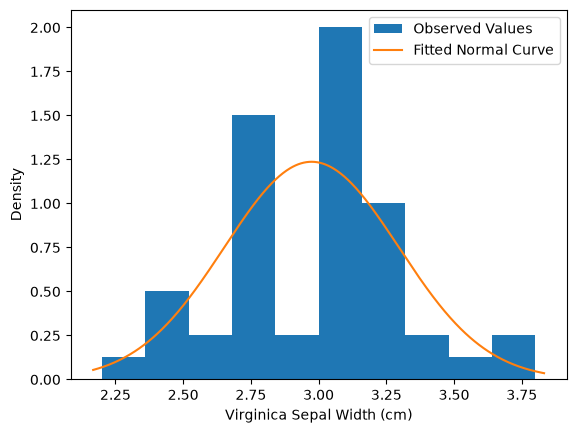

In [102]:
# 1. Select the sample, drop missing values, summarize, fit, and plot.
virginica_sepal_width = iris.loc[
    iris["variety"] == "Virginica",
    "sepal.width",
] #isolates rows with Virginica variety and takes the data from the sepal.wdith column

#Plot setup and statistical calculations
sample_mean = virginica_sepal_width.mean()
sample_std = virginica_sepal_width.std(ddof=1) #sample stdev with n-1 degrees of freedom (done automatically by pandas)
model = norm(loc = sample_mean,scale = sample_std) #creating normal model of sample
fitted_curve = np.linspace(virginica_sepal_width.min()-0.1*sample_std,virginica_sepal_width.max()+0.1*sample_std,500)

#Plotting
plt.hist(virginica_sepal_width,bins=10,density=True,label="Observed Values") #plotting an equal-width density histogram with 10 bins
plt.plot(fitted_curve,model.pdf(fitted_curve),linewidth = 1.5,label = "Fitted Normal Curve") #x, y, linewidth, title -- plotting best fit line
plt.xlabel("Virginica Sepal Width (cm)")
plt.ylabel("Density")
plt.legend()
#plt.tight_layout()
plt.show()

In [99]:
# 2. Compare percentages; calculate observed minus fitted in percentage points.
print("Area between 2.7cm and 3.3cm")
observed_diff = (virginica_sepal_width.between(2.7,3.3).mean())*100 #multiplying proportion to get %
fitted_diff = (model.cdf(3.3)-model.cdf(2.7))*100
print("Observed (%):",observed_diff, "\nFitted (%):",round(fitted_diff,2),"\nDifference (%) = ",round(observed_diff-fitted_diff,2)) #rounding to hundreths place

import math
# 3. Compare the sample and fitted 90th percentiles.
print("\n90th Percentiles")
#observed percentile 
virginica_array = np.array(virginica_sepal_width) #obtaining array
size_virginica = len(virginica_array) #getting number of components
percentile_adjustment = math.ceil((size_virginica/100)*90) #finding the entry number at which the 90th percentile would be found (assuming array is counted in ascending order)
#ceil (rounding up to nearest whole number) is chosen to ensure 90th percentile has been surpassed
observed_percentile = (np.sort(virginica_array))[percentile_adjustment] #sorting array in ascending order and finding 90th percentile value

fitted_percentile = model.ppf(0.9)
print("Observed:",observed_percentile, "\nFitted:",round(fitted_percentile,2), "\nDifference = ", round(observed_percentile-fitted_percentile,2))


Area between 2.7cm and 3.3cm
Observed (%): 76.0 
Fitted (%): 64.62 
Difference (%) =  11.38

90th Percentiles
Observed: 3.4 
Fitted: 3.39 
Difference =  0.01


Notes: The normal approximation had a notable difference between the observed data for the area between 2.7cm and 3.3cm, though the difference between the 90th percentile in the fitted and observed data was much less notable, only being around 0.01cm.

**Your interpretation:** Replace this text with 2–3 sentences.

Before saving, restart the kernel and run all cells. Check for errors and save your completed notebook.